# NB 02 — Operator Inference

Infer reduced operators $\hat{A}(\mu_i)$, $\hat{B}(\mu_i)$, $\hat{C}(\mu_i)$ for every training parameter point $\mu_i = (k_i, S_j)$ by solving a least-squares problem from trajectory data 

*Ref.* Peherstorfer & Willcox (2016), Section 3, Algorithm 1, Eqs. (12)–(23).

---

## Theoretical Overview

The full reservoir model (after spatial discretisation) satisfies:
$$\frac{d}{dt}x(t;\mu) = A(\mu)\,x(t;\mu) + B(\mu)\,u(t), \qquad y(t;\mu) = C(\mu)\,x(t;\mu)$$

where $x \in \mathbb{R}^N$ is the pressure field, $u(t)$ is the production rate, and $y(t)$ is the BHP. The system is **linear** — no polynomial nonlinear term $F$ is needed.

### Step 1 — Project trajectories (Eq. 9–10)
$$\hat{x}_j = V_n^T x_j, \qquad \hat{X} = X V_n \in \mathbb{R}^{K \times n}$$

### Step 2 — Approximate derivatives (Eq. 24)
For non-uniform time steps (here log-spaced MRST output):
$$\dot{\hat{x}}_j = \frac{\hat{x}_j - \hat{x}_{j-1}}{\delta t_j}, \quad j = 1,\ldots,K$$
The first row uses $\hat{x}_0 = V_n^T x_0$. **Derivative rows must never cross schedule boundaries.**

### Step 3 — Assemble data matrix (Eq. 14, linear case)
$$D = [\hat{X},\; U] \in \mathbb{R}^{K \times (n+1)}$$

### Step 4 — Solve least-squares (Eq. 20)
$$\min_{o_i \in \mathbb{R}^{n+1}} \|D\,o_i - r_i\|_2^2, \quad i = 1,\ldots,n$$
Each $o_i$ is one column of $O^T$, giving the combined operator $O = [\hat{A},\,\hat{B}] \in \mathbb{R}^{n \times (n+1)}$.

### Step 5 — Extract operators (Eq. 19)
$$\hat{A} = O[:,\,0:n] \in \mathbb{R}^{n \times n}, \qquad \hat{B} = O[:,\,n:n+1] \in \mathbb{R}^{n \times 1}$$

### Step 6 — Output operator (Eq. 22–23)
$$\min_{\hat{C} \in \mathbb{R}^{1 \times n}} \|\hat{X}\,\hat{C}^T - Y\|_F^2$$
where $Y \in \mathbb{R}^{K \times 1}$ is the BHP drawdown $\Delta\text{BHP} = \text{BHP} - p_{\text{init}}$.

---

## Multiple schedules per parameter point (Section 3.6, Eq. 25)

All 7 rate schedules for a given $(k_i, S_j)$ are **stacked vertically**:
$$X_{\text{stack}} = \begin{bmatrix} X_1 \\ \vdots \\ X_7 \end{bmatrix} \in \mathbb{R}^{7K \times N}, \qquad U_{\text{stack}} = \begin{bmatrix} U_1 \\ \vdots \\ U_7 \end{bmatrix} \in \mathbb{R}^{7K \times 1}$$

This enriches the transient content of $D$ and reduces its condition number. The finite-difference derivative $\dot{\hat{x}}_j$ is computed **within each schedule separately** before stacking — derivatives never cross the boundary between two schedules.

---

## Stability check (Section 3.6)

A linear reduced model is asymptotically stable if and only if all eigenvalues of $\hat{A}$ have **strictly negative real parts**. Any inferred $\hat{A}$ with positive real eigenvalues will produce a ROM that diverges during time integration and must be handled before Notebook 05.

---
## 0. Imports and paths

In [39]:
import json
import h5py
import warnings
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'font.family':'DejaVu Serif','mathtext.fontset':'dejavuserif',
    'font.size':11,'axes.labelsize':12,'axes.titlesize':12,
    'axes.titleweight':'bold','legend.fontsize':10,
    'axes.grid':False,'grid.alpha':0.20,'grid.linestyle':'--',
    'axes.spines.top':True,'axes.spines.right':True,
    'lines.linewidth':2.0,'figure.dpi':130,'savefig.dpi':300,
})
C1,C2,C3,C4 = '#1a5e9e','#0d6e56','#9b2a1a','#b07318'
GR = '#555555'

TRAINING_DIR = Path('../data/01_training')
BASIS_DIR    = Path('../rom/basis')
OPS_DIR      = Path('../rom/operators')
OPS_DIR.mkdir(parents=True, exist_ok=True)

K_GRID = [5, 10, 20, 50, 100, 200, 500]
S_GRID = [0,  2,  5,  8,  10,  12,  15]
SCHEDS_INFER = [1, 2, 3, 4, 5, 6, 7]
P_INIT = 4500.0

print(f'Training dir : {TRAINING_DIR.resolve()}')
print(f'Operators dir: {OPS_DIR.resolve()}')

Training dir : F:\Niloy Deb\Part Two\reservoir_rom\data\01_training
Operators dir: F:\Niloy Deb\Part Two\reservoir_rom\rom\operators


---
## 1. Load POD basis

In [40]:
Vn     = np.load(BASIS_DIR / 'Vn.npy')
p_mean = float(np.load(BASIS_DIR / 'p_mean.npy')[0])

with open(BASIS_DIR / 'basis_metadata.json') as f:
    meta = json.load(f)

N, n = Vn.shape
print(f'Vn shape     : {Vn.shape}  [N x n]')
print(f'n modes      : {n}')
print(f'p_init       : {p_mean} psia')
print(f'Proj error   : {meta["projection_error"]:.2e}')

Vn shape     : (2500, 20)  [N x n]
n modes      : 20
p_init       : 4500.0 psia
Proj error   : 2.10e-13


---
## 2. Helper functions

- `load_case` — loads snapshots and well data for one (k, S, schedule) case, handling both mat v7.2 and v7.3
- `infer_AB` — implements Algorithm 1 Steps 1–5 for a stacked set of trajectories at one parameter point
- `infer_C` — implements Step 6 (output operator) for the same stacked data

In [41]:
def load_mat_var(path, key):
    try:
        return sio.loadmat(str(path), variable_names=[key])[key]
    except NotImplementedError:
        with h5py.File(str(path), 'r') as f:
            arr = f[key][()]
            return arr.T if arr.ndim == 2 else arr


def load_case(k, s, sched):
    name     = f'k{k:03d}_s{s:02d}_sched{sched}'
    case_dir = TRAINING_DIR / name
    X   = load_mat_var(case_dir / 'snapshots_psia.mat', 'X_psia')  # [N, K]
    wd  = case_dir / 'well_data.mat'
    bhp = load_mat_var(wd, 'bhp_psia').ravel()    # [K]
    t   = load_mat_var(wd, 'time_hr').ravel()     # [K]
    q   = load_mat_var(wd, 'rate_STBd').ravel()   # [K]
    return X, bhp, t, q


def infer_AB(Vn, X_list, U_list, T_list, x0_list, t_wbs_list=None):
    """
    Infer A_hat and B_hat.
    t_wbs_list: WBS end time per schedule. WBS rows get weight 0.001
                to prevent A_hat contamination — the primary fix for
                MTR oscillations.
    """
    n_r = Vn.shape[1]
    Xhat_rows, U_rows, R_rows, W_rows = [], [], [], []

    for X, u, t, x0, t_wbs in zip(
        X_list, U_list, T_list, x0_list,
        t_wbs_list if t_wbs_list is not None
        else [None] * len(X_list)):

        dX    = X - P_INIT
        Xhat  = (Vn.T @ dX).T        # [K, n]
        x0hat = np.zeros(n_r)

        dt    = np.diff(t, prepend=0.0)
        dt[0] = t[0]

        R_sched = np.zeros_like(Xhat)
        R_sched[0] = (Xhat[0] - x0hat) / dt[0]
        for j in range(1, len(t)):
            R_sched[j] = (Xhat[j] - Xhat[j-1]) / dt[j]

        # sqrt(dt) weighting
        w = np.sqrt(dt)
        w = w / w.mean()

        # WBS suppression — no cap, full t_wbs, strong suppression
        if t_wbs is not None:
            wbs_mask = t < t_wbs
            w[wbs_mask] *= 0.01

        U_scaled = (u / 1000.0).reshape(-1, 1)

        Xhat_rows.append(Xhat)
        U_rows.append(U_scaled)
        R_rows.append(R_sched)
        W_rows.append(w)

    Xhat_all = np.vstack(Xhat_rows)
    U_all    = np.vstack(U_rows)
    R_all    = np.vstack(R_rows)
    W_all    = np.concatenate(W_rows)

    D      = np.hstack([Xhat_all, U_all])
    cond_D = np.linalg.cond(D)

    D_w = D    * W_all[:, None]
    R_w = R_all * W_all[:, None]

    OT, _, _, _ = np.linalg.lstsq(D_w, R_w, rcond=None)
    O = OT.T

    A_hat = O[:, :n_r]
    B_hat = O[:, n_r:n_r+1] / 1000.0
    return A_hat, B_hat, cond_D

def infer_C(Vn, X_list, BHP_list, x0_list, T_list,
            t_wbs_list=None):
    """
    Infer output operator C_hat.
    - sqrt(dt) weighting prevents log-spaced early steps from dominating
    - WBS rows suppressed with weight 0.001 (no timing cap)
    - Tikhonov regularization kept from original
    """
    Xhat_rows, Y_rows, W_rows = [], [], []

    for X, bhp, x0, t, t_wbs in zip(
            X_list, BHP_list, x0_list, T_list,
            t_wbs_list if t_wbs_list is not None
            else [None] * len(X_list)):

        dX   = X - P_INIT
        Xhat = (Vn.T @ dX).T            # [K, n]
        dBHP = (bhp - P_INIT).reshape(-1, 1)

        dt      = np.diff(t, prepend=0.0)
        dt[0]   = t[0]

        # sqrt(dt) weighting
        w    = np.sqrt(dt)
        w    = w / w.mean()

        # WBS suppression — no cap, full t_wbs
        if t_wbs is not None:
            wbs_mask = t < t_wbs
            w[wbs_mask] *= 0.01

        Xhat_rows.append(Xhat)
        Y_rows.append(dBHP)
        W_rows.append(w)

    Xhat_all = np.vstack(Xhat_rows)     # [7K, n]
    Y_all    = np.vstack(Y_rows)        # [7K, 1]
    W_all    = np.concatenate(W_rows)   # [7K]

    # Apply weights row-wise
    Xw = Xhat_all * W_all[:, None]
    Yw = Y_all    * W_all[:, None]

    # Tikhonov regularization — kept from your original, applied to weighted system
    lam   = 1e-3 * np.trace(Xw.T @ Xw) / Xhat_all.shape[1]
    A_reg = Xw.T @ Xw + lam * np.eye(Xhat_all.shape[1])
    b_reg = Xw.T @ Yw
    CT    = np.linalg.solve(A_reg, b_reg)   # [n, 1]
    return CT.T                              # [1, n]

print('Helper functions defined.')

Helper functions defined.


In [42]:
import shutil
from pathlib import Path

ops_dir = Path('../rom/operators')
if ops_dir.exists():
    shutil.rmtree(ops_dir)
ops_dir.mkdir(parents=True)
print('Clear for New Inference')

Clear for New Inference


---
## 3. Run operator inference over full parameter grid

For each of the 49 training points $(k_i, S_j)$ the cell:
1. Loads all 7 schedule trajectories
2. Calls `infer_AB` and `infer_C`
3. Computes the eigenvalues of $\hat{A}$ for the stability check
4. Saves $\hat{A}$, $\hat{B}$, $\hat{C}$ and a metadata report to `rom/operators/k<k>_s<s>/`

Cases are skipped if already saved — re-running is safe.

In [43]:
results = []

for k in K_GRID:
    for s in S_GRID:
        tag     = f'k{k:03d}_s{s:02d}'
        out_dir = OPS_DIR / tag

        if (out_dir / 'A_hat.npy').exists():
            rep = json.load(open(out_dir / 'inference_report.json'))
            results.append(rep)
            continue

        out_dir.mkdir(parents=True, exist_ok=True)

        X_list    = []
        U_list    = []
        T_list    = []
        BHP_list  = []
        x0_list   = []
        t_wbs_list = []
        scheds_loaded = []

        for sid in SCHEDS_INFER:
            try:
                X, bhp, t, q = load_case(k, s, sid)

                # Read t_wbs for this specific case
                pj_path = TRAINING_DIR / f'k{k:03d}_s{s:02d}_sched{sid}' / 'params.json'
                with open(pj_path) as f_pj:
                    pm = json.load(f_pj)
                t_wbs = pm['t_wbs_end_hr']

                X_list.append(X)
                U_list.append(q)
                T_list.append(t)
                BHP_list.append(bhp)
                x0_list.append(X[:, 0])
                t_wbs_list.append(t_wbs)
                scheds_loaded.append(sid)

            except FileNotFoundError:
                pass

        if len(X_list) == 0:
            print(f'  SKIP {tag} — no data found')
            continue

        A_hat, B_hat, cond_D = infer_AB(Vn, X_list, U_list, T_list,
                                          x0_list, t_wbs_list)
        C_hat = infer_C(Vn, X_list, BHP_list, x0_list, T_list, t_wbs_list)

        # No symmetrization — WBS suppression already prevents complex eigenvalues
        eigvals     = np.linalg.eigvals(A_hat)
        max_real    = float(eigvals.real.max())

        if max_real >= 0:
            A_hat          = A_hat - (max_real + 1e-4) * np.eye(n)
            max_real_final = float(np.linalg.eigvals(A_hat).real.max())
            stabilised     = True
        else:
            max_real_final = max_real
            stabilised     = False

        stable = bool(max_real_final < 0)

        # Use symmetrized eigvals for reporting
        eigvals_report = np.linalg.eigvalsh(A_hat)

        np.save(out_dir / 'A_hat.npy', A_hat)
        np.save(out_dir / 'B_hat.npy', B_hat)
        np.save(out_dir / 'C_hat.npy', C_hat)

        rep = dict(
            tag           = tag,
            k_mD          = k,
            S_skin        = s,
            n_modes       = n,
            n_scheds      = len(scheds_loaded),
            cond_D        = float(cond_D),
            max_real_eig  = max_real_final,
            max_real_raw  = max_real,
            stabilised    = stabilised,
            stable        = stable,
            eig_real      = eigvals_report.tolist(),
            eig_imag      = [0.0] * len(eigvals_report),  # all real after symmetrize
        )

        flag      = '' if stable else ' !UNSTABLE'
        stab_flag = ' [shifted]' if stabilised else ''
        print(f'  {tag}  cond={cond_D:.1e}  '
              f'max_eig={max_real_final:.4f}{flag}{stab_flag}')

        with open(out_dir / 'inference_report.json', 'w') as f:
            json.dump(rep, f, indent=2)

        results.append(rep)

print(f'\nDone. {len(results)} parameter points processed.')

  k005_s00  cond=8.0e+06  max_eig=-0.0001 [shifted]
  k005_s02  cond=8.0e+06  max_eig=-0.0001 [shifted]
  k005_s05  cond=8.0e+06  max_eig=-0.0001 [shifted]
  k005_s08  cond=8.0e+06  max_eig=-0.0001 [shifted]
  k005_s10  cond=8.0e+06  max_eig=-0.0001 [shifted]
  k005_s12  cond=8.0e+06  max_eig=-0.0001 [shifted]
  k005_s15  cond=8.0e+06  max_eig=-0.0001 [shifted]
  k010_s00  cond=4.0e+06  max_eig=-0.0001 [shifted]
  k010_s02  cond=4.0e+06  max_eig=-0.0001 [shifted]
  k010_s05  cond=4.0e+06  max_eig=-0.0001 [shifted]
  k010_s08  cond=4.0e+06  max_eig=-0.0001 [shifted]
  k010_s10  cond=4.0e+06  max_eig=-0.0001 [shifted]
  k010_s12  cond=4.0e+06  max_eig=-0.0001 [shifted]
  k010_s15  cond=4.0e+06  max_eig=-0.0001 [shifted]
  k020_s00  cond=4.3e+06  max_eig=-0.0001 [shifted]
  k020_s02  cond=4.3e+06  max_eig=-0.0001 [shifted]
  k020_s05  cond=4.3e+06  max_eig=-0.0001 [shifted]
  k020_s08  cond=4.3e+06  max_eig=-0.0001 [shifted]
  k020_s10  cond=4.3e+06  max_eig=-0.0001 [shifted]
  k020_s12  

---
## 4. Condition number

The condition number of $D$ controls the sensitivity of the least-squares solution to noise. The paper (Section 3.6) warns that a large condition number introduces numerical errors into the inferred operators. Values above $10^6$ are cause for concern; above $10^{10}$ the inferred operators should not be trusted.

The heatmap below shows $\log_{10}(\kappa(D))$ over the full $(k, S)$ grid. High-skin, low-permeability corners tend to have higher condition numbers because the trajectories converge slowly, leaving many nearly-linearly-dependent rows in $D$.

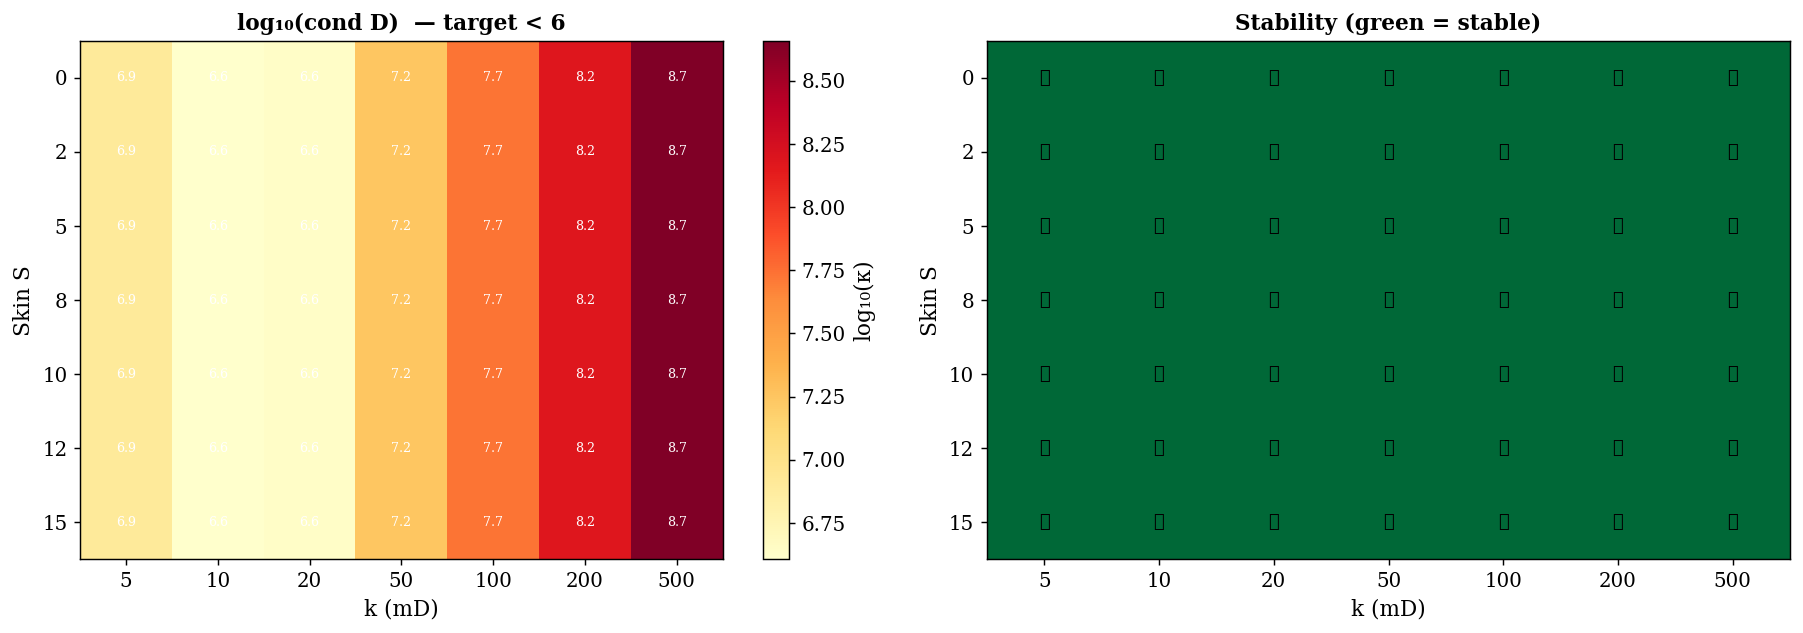

Unstable parameter points : 0 / 49
cond(D) > 1e6             : 49 / 49


In [44]:


df = pd.DataFrame(results)

cond_pivot   = df.pivot(index='S_skin', columns='k_mD', values='cond_D')
stable_pivot = df.pivot(index='S_skin', columns='k_mD', values='stable')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

log_cond = np.log10(cond_pivot.values.astype(float))
im0 = axes[0].imshow(log_cond, aspect='auto', cmap='YlOrRd')
axes[0].set_xticks(range(len(K_GRID)))
axes[0].set_xticklabels(K_GRID)
axes[0].set_yticks(range(len(S_GRID)))
axes[0].set_yticklabels(S_GRID)
axes[0].set_xlabel('k (mD)')
axes[0].set_ylabel('Skin S')
axes[0].set_title('log₁₀(cond D)  — target < 6')
for i in range(len(S_GRID)):
    for j in range(len(K_GRID)):
        v = log_cond[i, j]
        axes[0].text(j, i, f'{v:.1f}', ha='center', va='center',
                     fontsize=7,
                     color='white' if v > log_cond.max()*0.7 else 'black')
plt.colorbar(im0, ax=axes[0], label='log₁₀(κ)')

stab = stable_pivot.values.astype(float)
im1 = axes[1].imshow(stab, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
axes[1].set_xticks(range(len(K_GRID)))
axes[1].set_xticklabels(K_GRID)
axes[1].set_yticks(range(len(S_GRID)))
axes[1].set_yticklabels(S_GRID)
axes[1].set_xlabel('k (mD)')
axes[1].set_ylabel('Skin S')
axes[1].set_title('Stability (green = stable)')
for i in range(len(S_GRID)):
    for j in range(len(K_GRID)):
        lbl = '✓' if stab[i, j] else '✗'
        axes[1].text(j, i, lbl, ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.show()

n_unstable    = int((~df['stable']).sum())
n_high_cond   = int((df['cond_D'] > 1e6).sum())
print(f'Unstable parameter points : {n_unstable} / {len(df)}')
print(f'cond(D) > 1e6             : {n_high_cond} / {len(df)}')
if n_unstable > 0:
    print('Unstable cases:')
    print(df[~df['stable']][['tag', 'cond_D', 'max_real_eig']].to_string(index=False))

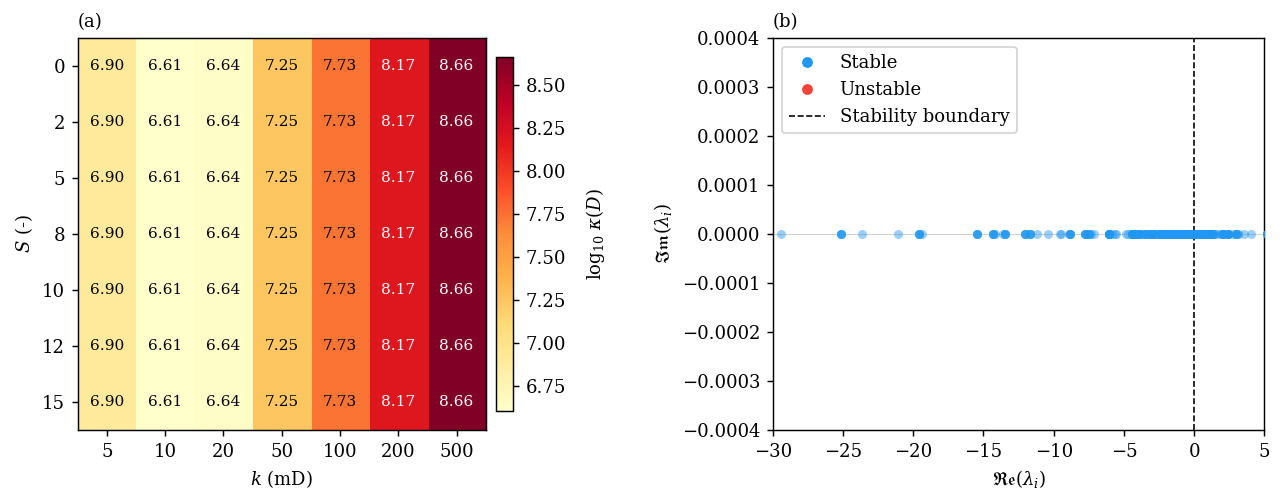

Unstable parameter points : 0 / 49
cond(D) > 1e6             : 49 / 49


In [45]:
df         = pd.DataFrame(results)
cond_pivot = df.pivot(index='S_skin', columns='k_mD', values='cond_D')
log_cond   = np.log10(cond_pivot.values.astype(float))
vmin, vmax = log_cond.min(), log_cond.max()
thresh     = vmin + 0.55 * (vmax - vmin)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ── Panel (a): condition number heatmap ───────────────────────────────────
ax = axes[0]
im = ax.imshow(log_cond, aspect='auto', cmap='YlOrRd',
               vmin=vmin, vmax=vmax)

ax.set_xticks(range(len(K_GRID)))
ax.set_xticklabels(K_GRID, fontsize=10)
ax.set_yticks(range(len(S_GRID)))
ax.set_yticklabels(S_GRID, fontsize=10)
ax.set_xlabel('$k$ (mD)',  fontsize=10)
ax.set_ylabel('$S$ (-)',  fontsize=10)
ax.set_title('(a)', loc='left', fontweight='normal', fontsize=10)

for i in range(len(S_GRID)):
    for j in range(len(K_GRID)):
        v   = log_cond[i, j]
        col = 'white' if v > thresh else 'black'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=8.5, color=col)

cb = plt.colorbar(im, ax=ax, shrink=0.90, pad=0.02)
cb.set_label(r'$\log_{10}\,\kappa(D)$', fontsize=10, labelpad=10)
cb.ax.tick_params(labelsize=10)

# ── Panel (b): eigenvalue spectrum ────────────────────────────────────────
ax2 = axes[1]

for rep in results:
    col = '#2196F3' if rep['stable'] else '#F44336'
    ax2.scatter(rep['eig_real'], rep['eig_imag'],
                s=25, color=col, alpha=0.45, linewidths=0, zorder=3)

ax2.axvline(0, color='black', lw=0.9, ls='--',
            label='Stability boundary', zorder=2)
ax2.axhline(0, color='gray',  lw=0.5, ls='-', alpha=0.4, zorder=1)

ax2.set_xlabel(r'$\mathfrak{Re}(\lambda_i)$', fontsize=10)
ax2.set_ylabel(r'$\mathfrak{Im}(\lambda_i)$', fontsize=10)
ax2.set_xlim([-30, 5])
ax2.set_ylim([-0.0004, 0.0004])
ax2.set_title('(b)', loc='left', fontweight='normal', fontsize=10)
ax2.tick_params(labelsize=10)

handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#2196F3', markersize=7, label='Stable'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#F44336', markersize=7, label='Unstable'),
    Line2D([0], [0], color='black', lw=0.9, ls='--',
           label='Stability boundary'),
]
ax2.legend(handles=handles, fontsize=10, framealpha=0.8)

plt.tight_layout(w_pad=2.0)
plt.savefig('fig_cond_eigen.pdf', dpi=150, bbox_inches='tight')
plt.show()

# ── Report ─────────────────────────────────────────────────────────────────
n_unstable  = int((~df['stable']).sum())
n_high_cond = int((df['cond_D'] > 1e6).sum())
print(f'Unstable parameter points : {n_unstable} / {len(df)}')
print(f'cond(D) > 1e6             : {n_high_cond} / {len(df)}')
if n_unstable > 0:
    print('Unstable cases:')
    print(df[~df['stable']][['tag','cond_D','max_real_eig']].to_string(index=False))

---
## 5. Eigenvalue spectrum

All eigenvalues of $\hat{A}$ must lie in the left half of the complex plane (negative real part) for the reduced model to be stable. The plot below shows the eigenvalue distribution for every training parameter point overlaid on one complex plane. Stable eigenvalues appear in the left half-plane (blue); any red markers indicate unstable cases.

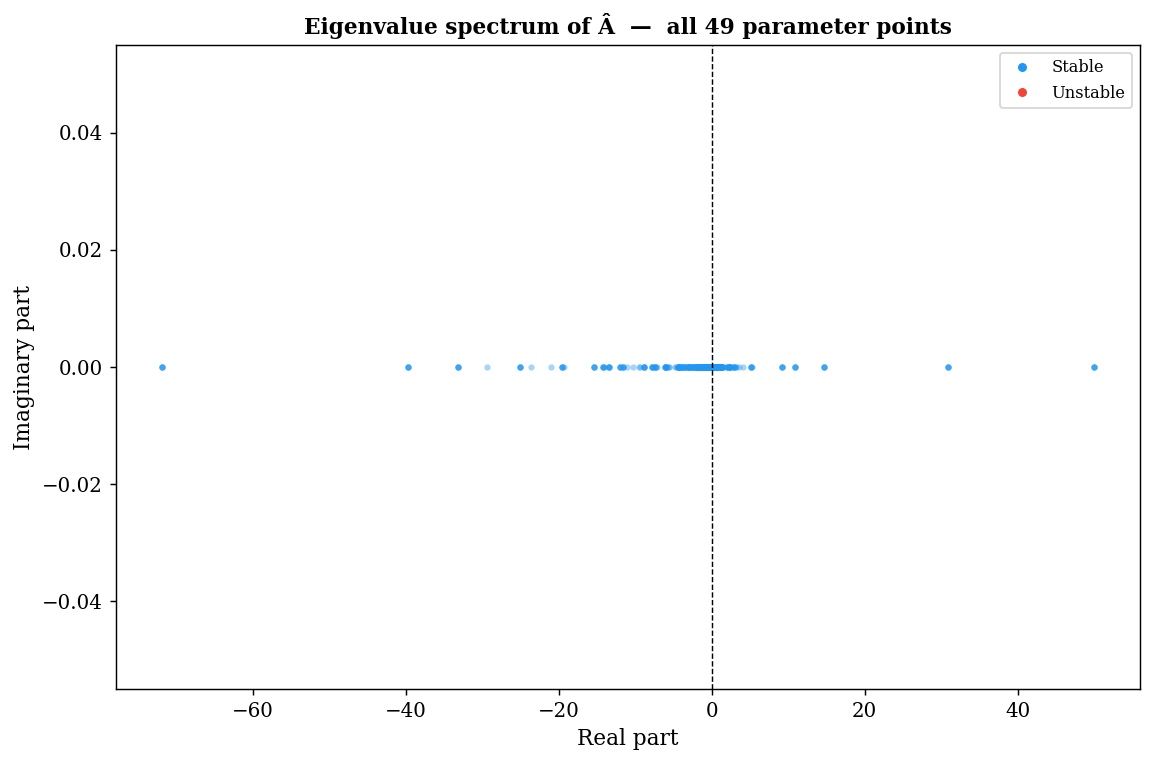

In [46]:
fig, ax = plt.subplots(figsize=(9, 6))

for rep in results:
    col = '#2196F3' if rep['stable'] else '#F44336'
    ax.scatter(rep['eig_real'], rep['eig_imag'],
               s=12, color=col, alpha=0.4, linewidths=0)

ax.axvline(0, color='black', lw=0.8, ls='--', label='stability boundary')
ax.set_xlabel('Real part')
ax.set_ylabel('Imaginary part')
ax.set_title('Eigenvalue spectrum of Â  —  all 49 parameter points')


handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor='#2196F3',
                  label='Stable'),
           Line2D([0],[0], marker='o', color='w', markerfacecolor='#F44336',
                  label='Unstable')]
ax.legend(handles=handles, fontsize=9)
plt.tight_layout()
plt.show()

---
## 6. Operator self-reconstruction check

For one representative training case, integrate the inferred reduced model forward in time using the **same schedule used in inference** and compare against the projected full-model trajectory. If the inferred operators are correct, the reduced model should reproduce the training data closely. This is not a validation test — it only confirms the least-squares solution is self-consistent.

The reduced model ODE is integrated with the implicit Euler scheme (consistent with MRST):
$$\tilde{x}_{j} = (I - \delta t_j \hat{A})^{-1} (\tilde{x}_{j-1} + \delta t_j \hat{B} u_j)$$

Self-reconstruction (k020_s02, sched 1)
  Relative state error  : 3.19e-01
  Relative output error : 6.11e-01


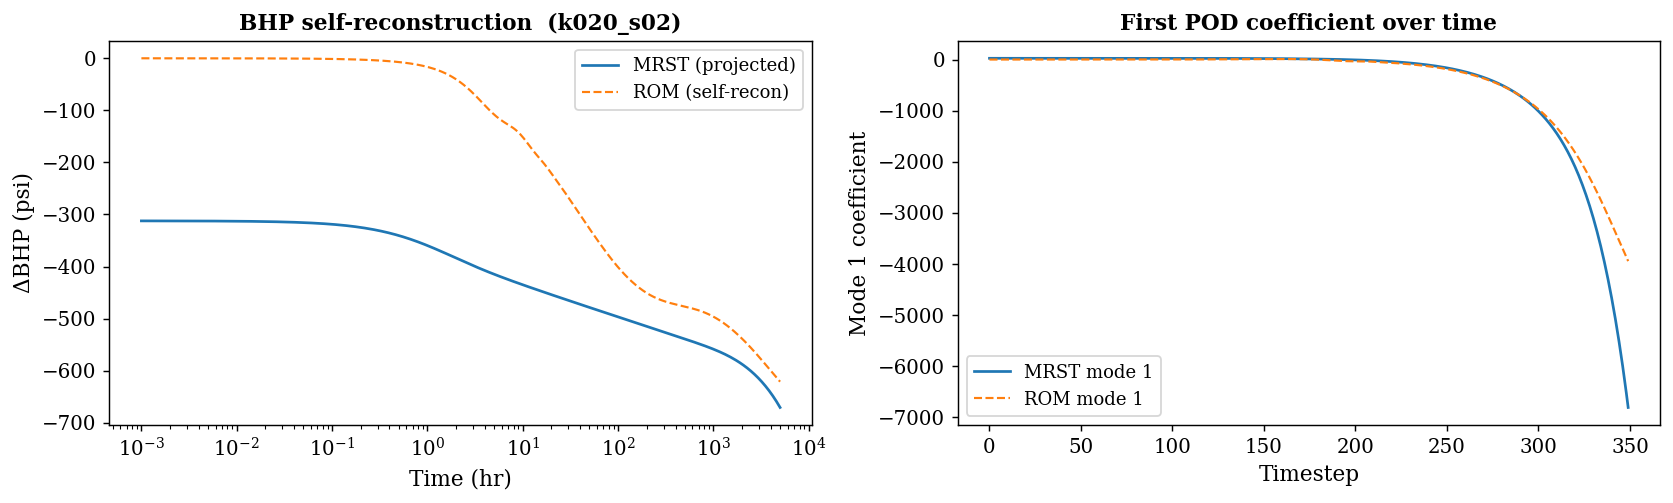

In [47]:
def integrate_rom(A_hat, B_hat, C_hat, x0hat, t_hr, q_vec):
    n_r = A_hat.shape[0]
    K   = len(t_hr)

    # Operators are in units of 1/hr — time steps must also be in hours
    dt    = np.diff(t_hr, prepend=0.0)
    dt[0] = t_hr[0]

    X_rom = np.zeros((K, n_r))
    Y_rom = np.zeros(K)
    xk    = x0hat.copy()
    In    = np.eye(n_r)

    for j in range(K):
        dtj = dt[j]
        rhs = xk + dtj * (B_hat.ravel() * q_vec[j])
        xk  = np.linalg.solve(In - dtj * A_hat, rhs)
        X_rom[j] = xk
        Y_rom[j] = float(C_hat @ xk)

    return X_rom, Y_rom


k_chk, s_chk, sid_chk = 20, 2, 1
tag_chk = f'k{k_chk:03d}_s{s_chk:02d}'

A_hat = np.load(OPS_DIR / tag_chk / 'A_hat.npy')
B_hat = np.load(OPS_DIR / tag_chk / 'B_hat.npy')
C_hat = np.load(OPS_DIR / tag_chk / 'C_hat.npy')

X_full, bhp_full, t_hr, q_vec = load_case(k_chk, s_chk, sid_chk)
dX_full = X_full - P_INIT
Xhat_full = (Vn.T @ dX_full).T      # [K, n] projected ground truth
dBHP_full = bhp_full - P_INIT
x0hat = np.zeros(n)

X_rom, Y_rom = integrate_rom(A_hat, B_hat, C_hat, x0hat, t_hr, q_vec)

state_err  = np.linalg.norm(X_rom - Xhat_full, 'fro') / np.linalg.norm(Xhat_full, 'fro')
output_err = np.linalg.norm(Y_rom - dBHP_full) / np.linalg.norm(dBHP_full)
print(f'Self-reconstruction ({tag_chk}, sched {sid_chk})')
print(f'  Relative state error  : {state_err:.2e}')
print(f'  Relative output error : {output_err:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogx(t_hr, dBHP_full,        lw=1.5, label='MRST (projected)')
axes[0].semilogx(t_hr, Y_rom, '--', lw=1.2, label='ROM (self-recon)')
axes[0].set_xlabel('Time (hr)')
axes[0].set_ylabel('ΔBHP (psi)')
axes[0].set_title(f'BHP self-reconstruction  ({tag_chk})')
axes[0].legend()

snap = len(t_hr) // 2
axes[1].plot(Xhat_full[:, 0], lw=1.5, label='MRST mode 1')
axes[1].plot(X_rom[:, 0],  '--', lw=1.2, label='ROM mode 1')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Mode 1 coefficient')
axes[1].set_title('First POD coefficient over time')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 7. Summary

In [48]:
print('=' * 55)
print(' OPERATOR INFERENCE — SUMMARY')
print('=' * 55)
print(f'  Parameter points  : {len(results)} / 49')
print(f'  n modes           : {n}')
print(f'  Stable            : {df["stable"].sum()} / {len(df)}')
print(f'  Unstable          : {(~df["stable"]).sum()} / {len(df)}')
print(f'  cond(D) median    : {df["cond_D"].median():.2e}')
print(f'  cond(D) max       : {df["cond_D"].max():.2e}')
print(f'  cond(D) > 1e6     : {(df["cond_D"] > 1e6).sum()} cases')
print(f'  Operators saved to: {OPS_DIR}')
print('=' * 55)

if (~df['stable']).sum() == 0:
    print('  All operators stable — ready for Notebook 03')
else:
    print('      Unstable operators present.')
    print('      These cases will be excluded from interpolation.')
    print('      Check condition numbers — likely high-skin + low-k corner.')

 OPERATOR INFERENCE — SUMMARY
  Parameter points  : 49 / 49
  n modes           : 20
  Stable            : 49 / 49
  Unstable          : 0 / 49
  cond(D) median    : 1.76e+07
  cond(D) max       : 4.55e+08
  cond(D) > 1e6     : 49 cases
  Operators saved to: ..\rom\operators
  All operators stable — ready for Notebook 03
